# Points samplling: AOI donor-discovery points

Generate an AOI-scoped point sample around the irrigated fields chunk, with heavy emphasis on
riparian and low-REM environments plus a small high-REM control sample.

| Step | Input | Output |
|------|-------|--------|
| 1. Load NB02 outputs | `fields_bounds.fgb`, `flowlines_bounds.fgb`, `rem_bounds.tif` | in-memory AOI inputs |
| 2. Sample points | config thresholds + AOI inputs | `points/points.fgb`, `points/points.parquet` |
| 3. Inspect sample | points + REM + fields | point map and group counts |


In [1]:
# Shared color palette
STREAM_BLUE = '#2171b5'
WET_CMAP = 'Blues'
TERRAIN_CMAP = 'terrain'
REM_CMAP = 'RdYlBu_r'
STRATA_COLORS = {
    'perennial': '#2166ac',
    'intermittent': '#74add1',
    'managed': '#4dac26',
    'non_partitioned': '#d9d9d9',
}
POINT_GROUP_COLORS = {
    'riparian': '#2166ac',
    'low_rem': '#67a9cf',
    'field_edge': '#1b7837',
    'high_rem_control': '#b2182b',
    'base': '#4d4d4d',
}
GROUP_ORDER = ['riparian', 'low_rem', 'field_edge', 'high_rem_control', 'base']


## 1. Setup

In [2]:
import os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr
import tomllib

from handily.config import HandilyConfig
from handily.io import aoi_from_bounds
from handily.points.sample import build_aoi_sample_points, write_sample_points

config_path = Path('beaverhead_config.toml')
with open(config_path, 'rb') as f:
    config = HandilyConfig.from_dict(tomllib.load(f))

out_dir = config.out_dir
points_out_dir = config.points_out_dir or os.path.join(out_dir, 'points')
os.makedirs(points_out_dir, exist_ok=True)

print(f'Config:          {config_path}')
print(f'Output dir:      {out_dir}')
print(f'Points out dir:  {points_out_dir}')
print(f'Bounds:          {config.bounds}')


Config:          beaverhead_config.toml
Output dir:      /nas/handily/handily/beaverhead/outputs/
Points out dir:  /nas/handily/handily/beaverhead/outputs/points
Bounds:          [-112.418, 45.445, -112.353, 45.49]


## 2. Load NB02 outputs

These files were produced by `02_terrain_analysis.ipynb`.

In [3]:
fields_path = os.path.join(out_dir, 'fields_bounds.fgb')
flowlines_path = os.path.join(out_dir, 'flowlines_bounds.fgb')
rem_path = os.path.join(out_dir, 'rem_bounds.tif')

fields = gpd.read_file(fields_path)
flowlines = gpd.read_file(flowlines_path)
rem_da = rxr.open_rasterio(rem_path, masked=True).squeeze('band', drop=True)

aoi = aoi_from_bounds(tuple(config.bounds))

print(f'Fields:    {len(fields)} polygons')
print(f'Flowlines: {len(flowlines)} segments')
print(f'REM:       {rem_da.shape}  CRS={rem_da.rio.crs}')


Fields:    48 polygons
Flowlines: 253 segments
REM:       (5798, 5864)  CRS=EPSG:5070


## 3. Generate AOI sample points

This calls the new AOI-scoped sampler directly from the notebook, using the REM, field polygons,
and flowlines already produced for the same AOI.


In [4]:
points = build_aoi_sample_points(
    aoi_gdf=aoi,
    fields=fields.to_crs(rem_da.rio.crs),
    rem_da=rem_da,
    flowlines=flowlines.to_crs(rem_da.rio.crs),
    config=config,
    aoi_id='bounds',
)

paths = write_sample_points(points, points_out_dir)

print(f'Points total: {len(points)}')
print('Group counts:')
print(points['sample_group'].value_counts().to_string())
print(f"Saved → {paths['fgb']}")
print(f"Saved → {paths['parquet']}")
print(points.head())


Unmapped FCODE values (will be excluded): [55800]


Points total: 310
Group counts:
sample_group
low_rem             100
riparian            100
field_edge           50
base                 50
high_rem_control     10
Saved → /nas/handily/handily/beaverhead/outputs/points/points.fgb
Saved → /nas/handily/handily/beaverhead/outputs/points/points.parquet
        point_id  aoi_id                          geometry             x  \
0  bounds_000000  bounds  POINT (-1276406.372 2607369.321) -1.276406e+06   
1  bounds_000001  bounds  POINT (-1276406.372 2607549.321) -1.276406e+06   
2  bounds_000002  bounds  POINT (-1276346.372 2607309.321) -1.276346e+06   
3  bounds_000003  bounds  POINT (-1276346.372 2607369.321) -1.276346e+06   
4  bounds_000004  bounds  POINT (-1276346.372 2607729.321) -1.276346e+06   

              y sample_group  sample_seed  in_irrigated_lands  rem_at_sample  \
0  2.607369e+06   field_edge           42               False       1.733154   
1  2.607549e+06   field_edge           42               False       2.167114   
2 

## 4. Static feature extraction

Augments each sampled point with per-category stream distances and a REM bin label.
These columns depend only on the REM raster and flowlines — no EE export needed.

| New column | Description |
|------------|-------------|
| `dist_perennial_m` | Distance to nearest perennial flowline (m) |
| `dist_intermittent_m` | Distance to nearest intermittent flowline (m) |
| `dist_managed_m` | Distance to nearest canal / ditch (m) |
| `rem_bin` | REM class: "0-1 m", "1-2 m", "2-5 m", "5-10 m", ">10 m" |


In [5]:
import numpy as np

from handily.points.static_features import extract_static_point_features, write_static_features

if len(points) == 0:
    print('[SKIP] No points — skipping static feature extraction.')
    points_static = points.copy()
else:
    points_static = extract_static_point_features(
        points=points,
        flowlines=flowlines.to_crs(rem_da.rio.crs),
    )
    static_paths = write_static_features(points_static, points_out_dir)

    new_cols = [c for c in points_static.columns if c not in points.columns]
    print(f'New columns: {new_cols}')
    print(f"Saved → {static_paths['fgb']}")
    print(f"Saved → {static_paths['parquet']}")
    print()
    print('rem_bin distribution:')
    print(points_static['rem_bin'].value_counts().sort_index().to_string())
    print()
    dist_cols = ['dist_perennial_m', 'dist_intermittent_m', 'dist_managed_m']
    print('Per-category stream distances (m):')
    print(points_static[dist_cols].replace(np.inf, np.nan).describe().round(1).to_string())


Unmapped FCODE values (will be excluded): [55800]


New columns: ['dist_perennial_m', 'dist_intermittent_m', 'dist_managed_m', 'rem_bin']
Saved → /nas/handily/handily/beaverhead/outputs/points/points_static.fgb
Saved → /nas/handily/handily/beaverhead/outputs/points/points_static.parquet

rem_bin distribution:
rem_bin
0-1 m      63
1-2 m     186
2-5 m      43
5-10 m      5
>10 m      13

Per-category stream distances (m):
       dist_perennial_m  dist_intermittent_m  dist_managed_m
count             310.0                310.0           310.0
mean              340.7                684.6           255.5
std               242.5                455.1           195.4
min                 1.1                  0.1             0.7
25%               129.0                301.2            85.3
50%               310.3                614.5           228.5
75%               523.7               1011.2           379.7
max              1118.3               1693.0           978.7


## 5. Sample summary

In [6]:
summary = pd.DataFrame({
    'count': points['sample_group'].value_counts(),
    'in_fields': points.groupby('sample_group')['in_irrigated_lands'].sum(),
    'mean_rem': points.groupby('sample_group')['rem_at_sample'].mean().round(2),
    'mean_stream_distance_m': points.groupby('sample_group')['stream_distance'].mean().round(1),
}).fillna(0)
summary


,count,in_fields,mean_rem,mean_stream_distance_m
sample_group,,,,
base,50,18,1.66,152.2
field_edge,50,23,2.05,138.8
high_rem_control,10,8,11.26,123.3
low_rem,100,45,1.30,139.8
riparian,100,34,1.71,90.1


## 6. Visualizations

Four panels explore the sample structure:

| Section | What it shows |
|---------|---------------|
| **6a. Map overview** | REM base + flowlines by stream type; points colored by group |
| **6b. Group composition** | Point counts, irrigated-land membership, nearest stream type |
| **6c. Hydro-topographic targeting** | REM histogram and stream-distance vs REM scatter per group |
| **6d. Per-group distributions** | Violin plots of REM and stream distance per group |


### 6a. Map overview

Left: REM surface + NHD flowlines by stream type + field boundaries.
Right: same REM base + sample points colored by group.


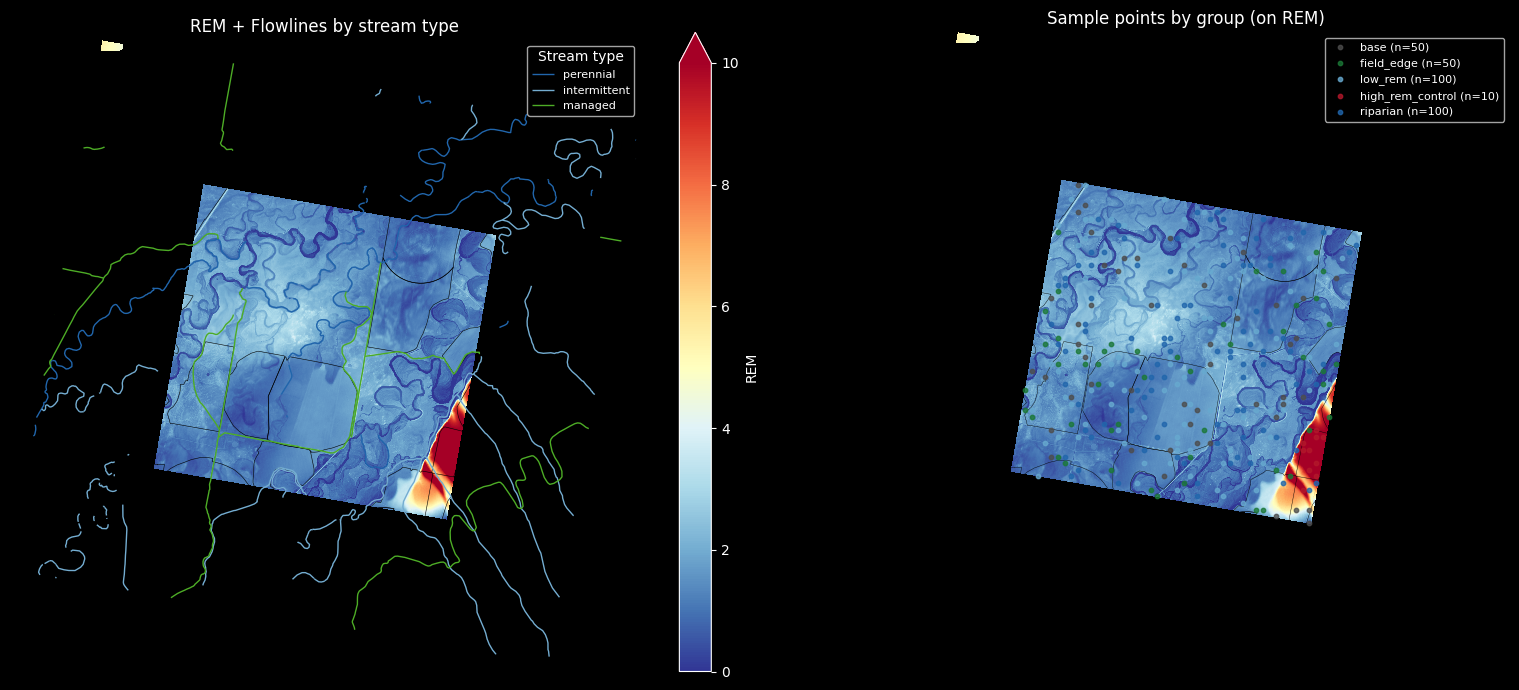

In [7]:
import numpy as np

if len(points) == 0:
    print('[SKIP] No points — skipping map overview.')
else:
    from handily.nhd import FCODE_CATEGORIES

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # --- Left: REM base + flowlines by category + field boundaries ---
    rem_da.plot(ax=axes[0], cmap=REM_CMAP, vmin=0, vmax=10, add_colorbar=True)
    fcode_col = 'fcode' if 'fcode' in flowlines.columns else 'FCODE'
    cats = flowlines[fcode_col].map(FCODE_CATEGORIES).fillna('unknown')
    for cat, color in [('perennial', STRATA_COLORS['perennial']),
                       ('intermittent', STRATA_COLORS['intermittent']),
                       ('managed', STRATA_COLORS['managed'])]:
        sub = flowlines[cats == cat].to_crs(rem_da.rio.crs)
        if len(sub):
            sub.plot(ax=axes[0], color=color, linewidth=1.0, label=cat)
    fields.to_crs(rem_da.rio.crs).plot(ax=axes[0], color='none', edgecolor='black', linewidth=0.4)
    axes[0].set_title('REM + Flowlines by stream type')
    axes[0].legend(fontsize=8, loc='upper right', title='Stream type')
    axes[0].set_axis_off()

    # --- Right: REM base + fields + points colored by group ---
    rem_da.plot(ax=axes[1], cmap=REM_CMAP, vmin=0, vmax=10, add_colorbar=False)
    fields.to_crs(rem_da.rio.crs).plot(ax=axes[1], color='none', edgecolor='black', linewidth=0.3)
    for group in ['base', 'field_edge', 'low_rem', 'high_rem_control', 'riparian']:
        grp = points[points['sample_group'] == group].to_crs(rem_da.rio.crs)
        if len(grp) == 0:
            continue
        grp.plot(
            ax=axes[1],
            color=POINT_GROUP_COLORS[group],
            markersize=10,
            label=f'{group} (n={len(grp)})',
            alpha=0.8,
        )
    axes[1].set_title('Sample points by group (on REM)')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


### 6b. Group composition

Three panels summarise how the sample is distributed across groups: absolute counts (A),
irrigated-land membership (B), and nearest stream type (C).


/tmp/ipykernel_3618130/1198362281.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop = points.groupby('sample_group').apply(
/tmp/ipykernel_3618130/1198362281.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prop = points.groupby('sample_group').apply(
/tmp/ipykernel_3618130/1198362281.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a futur

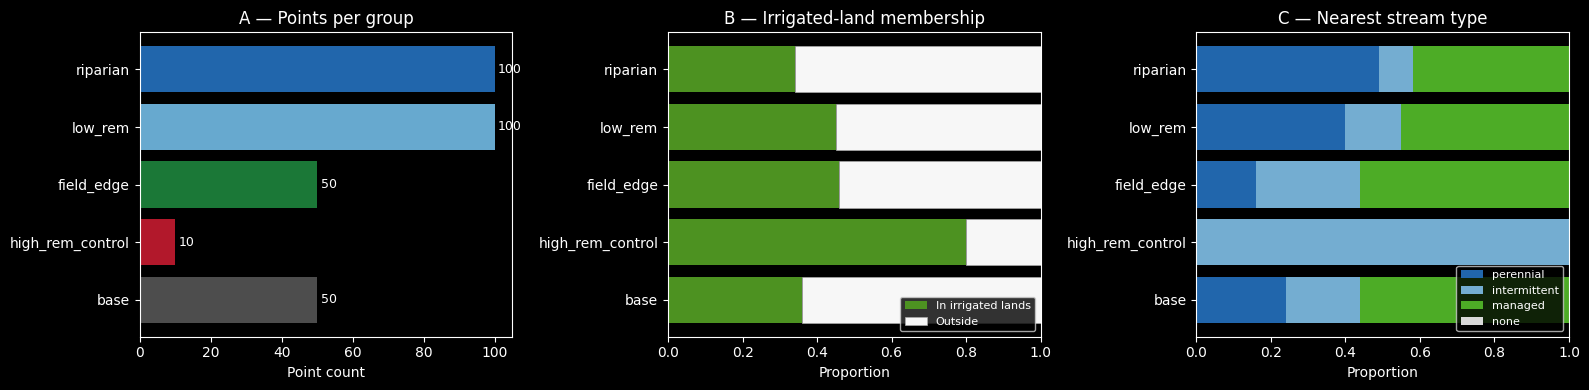

In [8]:
if len(points) == 0:
    print('[SKIP] No points — skipping group composition.')
else:
    groups_present = [g for g in GROUP_ORDER if g in points['sample_group'].values]
    counts = points['sample_group'].value_counts().reindex(groups_present, fill_value=0)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # --- Panel A: point count per group ---
    colors_a = [POINT_GROUP_COLORS[g] for g in groups_present]
    bars = axes[0].barh(groups_present, counts.values, color=colors_a)
    for bar, val in zip(bars, counts.values):
        axes[0].text(bar.get_width() + max(counts.values) * 0.01, bar.get_y() + bar.get_height() / 2,
                     str(val), va='center', fontsize=9)
    axes[0].set_xlabel('Point count')
    axes[0].set_title('A — Points per group')
    axes[0].invert_yaxis()

    # --- Panel B: irrigated-land membership ---
    in_irr = points.groupby('sample_group')['in_irrigated_lands'].mean().reindex(groups_present, fill_value=0)
    out_irr = 1 - in_irr
    axes[1].barh(groups_present, in_irr.values, color='#4d9221', label='In irrigated lands')
    axes[1].barh(groups_present, out_irr.values, left=in_irr.values, color='#f7f7f7',
                 edgecolor='#aaaaaa', linewidth=0.5, label='Outside')
    axes[1].set_xlabel('Proportion')
    axes[1].set_title('B — Irrigated-land membership')
    axes[1].set_xlim(0, 1)
    axes[1].legend(fontsize=8, loc='lower right')
    axes[1].invert_yaxis()

    # --- Panel C: nearest stream type per group ---
    stream_types = ['perennial', 'intermittent', 'managed', 'none']
    stream_colors = [STRATA_COLORS.get(s, '#d9d9d9') for s in stream_types]
    lefts = np.zeros(len(groups_present))
    for st, color in zip(stream_types, stream_colors):
        prop = points.groupby('sample_group').apply(
            lambda df: (df['nearest_stream_type'] == st).mean()
        ).reindex(groups_present, fill_value=0)
        axes[2].barh(groups_present, prop.values, left=lefts, color=color, label=st)
        lefts += prop.values
    axes[2].set_xlabel('Proportion')
    axes[2].set_title('C — Nearest stream type')
    axes[2].set_xlim(0, 1)
    axes[2].legend(fontsize=8, loc='lower right')
    axes[2].invert_yaxis()

    plt.tight_layout()
    plt.show()


### 6c. Hydro-topographic targeting

Panel A shows how each group occupies REM space relative to the low and high thresholds.
Panel B reveals the 2D sampling envelope in stream-distance × REM space.


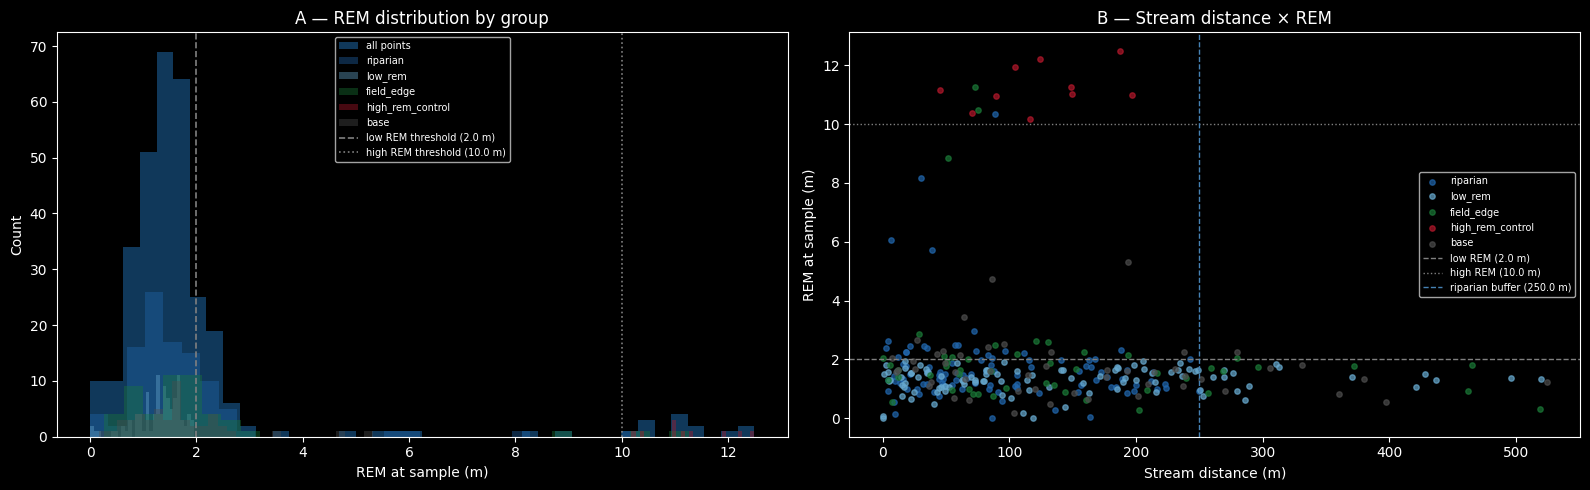

In [9]:
if len(points) == 0:
    print('[SKIP] No points — skipping hydro-topographic targeting.')
else:
    low_thr = config.points_low_rem_threshold_m
    high_thr = config.points_high_rem_threshold_m
    rip_buf = config.points_riparian_buffer_m

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # --- Panel A: REM histogram ---
    rem_all = points['rem_at_sample'].replace([np.inf, -np.inf], np.nan).dropna()
    if len(rem_all) > 0:
        axes[0].hist(rem_all, bins=40, color=STREAM_BLUE, alpha=0.5, label='all points')
        for group in GROUP_ORDER:
            sub = points.loc[points['sample_group'] == group, 'rem_at_sample']
            sub = sub.replace([np.inf, -np.inf], np.nan).dropna()
            if len(sub) == 0:
                continue
            axes[0].hist(sub, bins=30, color=POINT_GROUP_COLORS[group], alpha=0.4, label=group)
        axes[0].axvline(low_thr, color='grey', linestyle='--', linewidth=1.2,
                        label=f'low REM threshold ({low_thr} m)')
        axes[0].axvline(high_thr, color='grey', linestyle=':', linewidth=1.2,
                        label=f'high REM threshold ({high_thr} m)')
        axes[0].set_xlabel('REM at sample (m)')
        axes[0].set_ylabel('Count')
        axes[0].set_title('A — REM distribution by group')
        axes[0].legend(fontsize=7)
    else:
        axes[0].text(0.5, 0.5, 'No valid REM values', ha='center', va='center',
                     transform=axes[0].transAxes)

    # --- Panel B: stream distance vs REM scatter ---
    dist_all = points['stream_distance'].replace([np.inf, -np.inf], np.nan)
    rem_col = points['rem_at_sample'].replace([np.inf, -np.inf], np.nan)
    valid_mask = dist_all.notna() & rem_col.notna()
    if valid_mask.sum() > 0:
        for group in GROUP_ORDER:
            mask = (points['sample_group'] == group) & valid_mask
            if mask.sum() == 0:
                continue
            axes[1].scatter(
                dist_all[mask], rem_col[mask],
                color=POINT_GROUP_COLORS[group], s=15, alpha=0.7, label=group,
            )
        axes[1].axhline(low_thr, color='grey', linestyle='--', linewidth=1.0,
                        label=f'low REM ({low_thr} m)')
        axes[1].axhline(high_thr, color='grey', linestyle=':', linewidth=1.0,
                        label=f'high REM ({high_thr} m)')
        axes[1].axvline(rip_buf, color='steelblue', linestyle='--', linewidth=1.0,
                        label=f'riparian buffer ({rip_buf} m)')
        axes[1].set_xlabel('Stream distance (m)')
        axes[1].set_ylabel('REM at sample (m)')
        axes[1].set_title('B — Stream distance × REM')
        axes[1].legend(fontsize=7)
    else:
        axes[1].text(0.5, 0.5, 'No valid distance/REM values', ha='center', va='center',
                     transform=axes[1].transAxes)

    plt.tight_layout()
    plt.show()


### 6d. Per-group distributions

Violin plots show the spread of REM and stream distance within each group.
Groups with fewer than 2 valid observations are omitted.


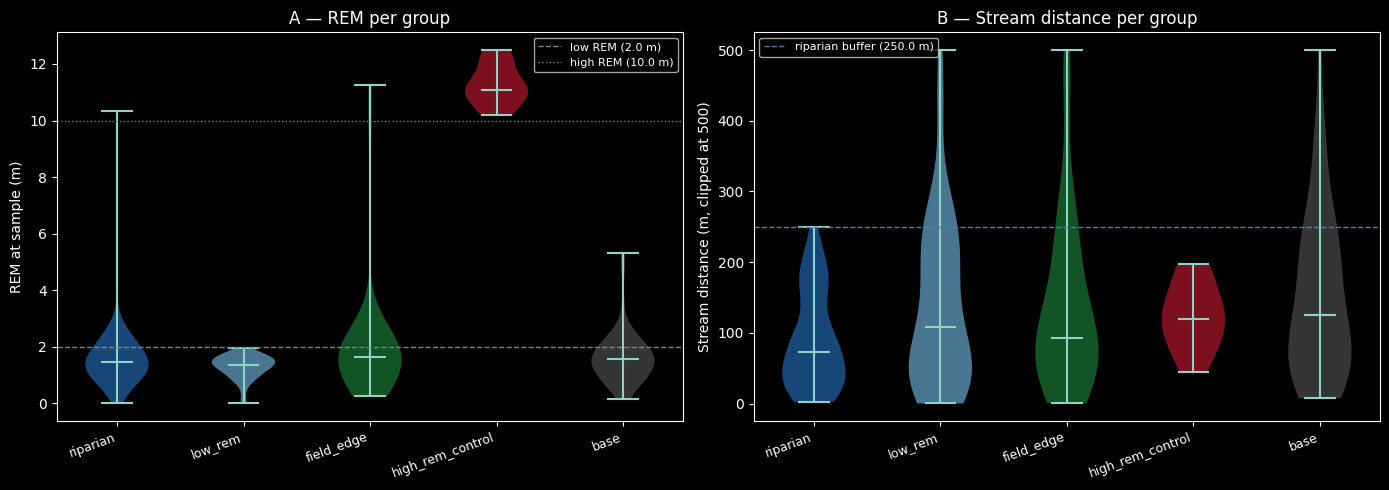

In [10]:
if len(points) == 0:
    print('[SKIP] No points — skipping per-group distributions.')
else:
    low_thr = config.points_low_rem_threshold_m
    high_thr = config.points_high_rem_threshold_m
    rip_buf = config.points_riparian_buffer_m

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    groups_present = [g for g in GROUP_ORDER if g in points['sample_group'].values]

    # --- Panel A: REM violin per group ---
    rem_data = []
    rem_labels = []
    rem_colors = []
    for group in groups_present:
        vals = (points.loc[points['sample_group'] == group, 'rem_at_sample']
                .replace([np.inf, -np.inf], np.nan).dropna())
        if len(vals) >= 2:
            rem_data.append(vals.values)
            rem_labels.append(group)
            rem_colors.append(POINT_GROUP_COLORS[group])

    if rem_data:
        parts = axes[0].violinplot(rem_data, showmedians=True)
        for pc, color in zip(parts['bodies'], rem_colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        axes[0].set_xticks(range(1, len(rem_labels) + 1))
        axes[0].set_xticklabels(rem_labels, rotation=20, ha='right', fontsize=9)
        axes[0].axhline(low_thr, color='grey', linestyle='--', linewidth=1.0,
                        label=f'low REM ({low_thr} m)')
        axes[0].axhline(high_thr, color='grey', linestyle=':', linewidth=1.0,
                        label=f'high REM ({high_thr} m)')
        axes[0].set_ylabel('REM at sample (m)')
        axes[0].set_title('A — REM per group')
        axes[0].legend(fontsize=8)
    else:
        axes[0].text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                     transform=axes[0].transAxes)

    # --- Panel B: stream distance violin per group (clipped at 500 m) ---
    dist_data = []
    dist_labels = []
    dist_colors = []
    for group in groups_present:
        vals = (points.loc[points['sample_group'] == group, 'stream_distance']
                .replace([np.inf, -np.inf], np.nan).dropna()
                .clip(upper=500.0))
        if len(vals) >= 2:
            dist_data.append(vals.values)
            dist_labels.append(group)
            dist_colors.append(POINT_GROUP_COLORS[group])

    if dist_data:
        parts = axes[1].violinplot(dist_data, showmedians=True)
        for pc, color in zip(parts['bodies'], dist_colors):
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        axes[1].set_xticks(range(1, len(dist_labels) + 1))
        axes[1].set_xticklabels(dist_labels, rotation=20, ha='right', fontsize=9)
        axes[1].axhline(rip_buf, color='steelblue', linestyle='--', linewidth=1.0,
                        label=f'riparian buffer ({rip_buf} m)')
        axes[1].set_ylabel('Stream distance (m, clipped at 500)')
        axes[1].set_title('B — Stream distance per group')
        axes[1].legend(fontsize=8)
    else:
        axes[1].text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                     transform=axes[1].transAxes)

    plt.tight_layout()
    plt.show()


## 7. Earth Engine point exports

With the sample points reviewed, the next step is to export Landsat-scale time-series data
for those points. The export path writes:

- annual IrrMapper values
- annual growing-season NDVI summaries
- monthly OpenET v2.0 ensemble ETa

The cells below first preview the export names and destinations, then optionally submit the
Earth Engine tasks.

In [11]:
from handily.points.ee_extract import (
    build_points_export_prefix,
    export_points_products_from_config,
)

year_start = config.points_year_start
year_end = config.points_year_end
aoi_id = points['aoi_id'].iloc[0]

for product in ['irrmapper', 'ndvi', 'openet_eta']:
    prefix, description = build_points_export_prefix(
        config,
        product=product,
        aoi_id=aoi_id,
        year_start=year_start,
        year_end=year_end,
    )
    print(f'{product}:')
    print(f'  description: {description}')
    print(f'  bucket path:  gs://{config.points_ee_bucket or config.et_bucket}/{prefix}.csv')


irrmapper:
  description: beaverhead_bounds_irrmapper_points_2017_2021
  bucket path:  gs://wudr/handily/beaverhead/points/irrmapper/beaverhead_bounds_irrmapper_points_2017_2021.csv
ndvi:
  description: beaverhead_bounds_ndvi_points_2017_2021
  bucket path:  gs://wudr/handily/beaverhead/points/ndvi/beaverhead_bounds_ndvi_points_2017_2021.csv
openet_eta:
  description: beaverhead_bounds_openet_eta_points_2017_2021
  bucket path:  gs://wudr/handily/beaverhead/points/openet_eta/beaverhead_bounds_openet_eta_points_2017_2021.csv


In [12]:
RUN_EE_EXPORTS = False

if RUN_EE_EXPORTS:
    results = export_points_products_from_config(config, points=points, product='all')
    pd.DataFrame(results)
else:
    print('Set RUN_EE_EXPORTS = True to submit IrrMapper, NDVI, and OpenET ETa point exports.')
    print('This cell uses the in-memory `points` GeoDataFrame from above, so rerun the sampling cell if you change the sample.')
    print(f'Export years: {config.points_year_start} to {config.points_year_end}')
    print(f'Destination:  {config.points_ee_dest}')
    print(f'Bucket:       {config.points_ee_bucket or config.et_bucket}')


Set RUN_EE_EXPORTS = True to submit IrrMapper, NDVI, and OpenET ETa point exports.
This cell uses the in-memory `points` GeoDataFrame from above, so rerun the sampling cell if you change the sample.
Export years: 2017 to 2021
Destination:  bucket
Bucket:       wudr


## 8. Sync downloaded tables

After the Earth Engine tasks finish, sync the exported CSV tables from GCS into the local
mirrored `points/` folders.

In [13]:
from handily.bucket import sync_bucket_to_local

RUN_SYNC = False
point_subdirs = ['points/irrmapper', 'points/ndvi', 'points/openet_eta']

if RUN_SYNC:
    synced = []
    for subdir in point_subdirs:
        result = sync_bucket_to_local(
            bucket=config.points_ee_bucket or config.et_bucket,
            bucket_prefix=f'{config.bucket_prefix}/{config.project_name}',
            local_root=config.local_data_root,
            subdir=subdir,
            glob_pattern='*.csv',
            overwrite=False,
            dry_run=False,
        )
        synced.append({'subdir': subdir, **{k: result[k] for k in ['copied', 'skipped', 'errors']}})
    pd.DataFrame(synced)
else:
    print('Set RUN_SYNC = True after the EE export tasks finish.')
    for subdir in point_subdirs:
        print(f'Will sync: gs://{config.points_ee_bucket or config.et_bucket}/{config.bucket_prefix}/{config.project_name}/{subdir}/')
        if config.local_data_root:
            print(f'  -> {config.local_data_root}/{config.bucket_prefix}/{config.project_name}/{subdir}/')


Set RUN_SYNC = True after the EE export tasks finish.
Will sync: gs://wudr/handily/beaverhead/points/irrmapper/
  -> /nas/handily/handily/beaverhead/points/irrmapper/
Will sync: gs://wudr/handily/beaverhead/points/ndvi/
  -> /nas/handily/handily/beaverhead/points/ndvi/
Will sync: gs://wudr/handily/beaverhead/points/openet_eta/
  -> /nas/handily/handily/beaverhead/points/openet_eta/


## 9. Inspect downloaded EE tables

Verifies that all three EE exports join cleanly to the point sample and demonstrates the
Milestone 1 success criterion: annual records can be joined back to points without ambiguity.

Derived metrics per group show the signal structure the behavioral clustering will use in the next notebook.

In [14]:
import os

year_start = config.points_year_start or 2017
year_end   = config.points_year_end   or 2021

def _local_ee_csv(config, product, aoi_name):
    filename = f'{config.project_name}_{aoi_name}_{product}_points_{year_start}_{year_end}.csv'
    return config.get_local_path(f'points/{product}', filename)

aoi_name = points_static['aoi_id'].iloc[0] if len(points_static) > 0 else 'bounds'

paths_ee = {
    'irrmapper':  _local_ee_csv(config, 'irrmapper',  aoi_name),
    'ndvi':       _local_ee_csv(config, 'ndvi',       aoi_name),
    'openet_eta': _local_ee_csv(config, 'openet_eta', aoi_name),
}
for label, path in paths_ee.items():
    tag = '[OK]     ' if os.path.exists(path) else '[MISSING]'
    print(f'{tag} {label}: {os.path.basename(path)}')

print()
for label, path in paths_ee.items():
    if not os.path.exists(path):
        continue
    df = pd.read_csv(path)
    matched = df['point_id'].isin(points_static['point_id']).sum()
    print(f'{label}: {matched}/{len(points_static)} point_ids matched  ({df.shape[0]} rows, {df.shape[1]} cols)')


[OK]      irrmapper: beaverhead_bounds_irrmapper_points_2017_2021.csv
[OK]      ndvi: beaverhead_bounds_ndvi_points_2017_2021.csv
[OK]      openet_eta: beaverhead_bounds_openet_eta_points_2017_2021.csv

irrmapper: 310/310 point_ids matched  (310 rows, 15 cols)
ndvi: 310/310 point_ids matched  (310 rows, 35 cols)
openet_eta: 310/310 point_ids matched  (310 rows, 70 cols)


## 10. Long-term feature table

In [15]:
from handily.points.time_series import build_point_year_table, write_point_year

point_year = build_point_year_table(
    irrmapper_csv=paths_ee['irrmapper'],
    ndvi_csv=paths_ee['ndvi'],
    openet_eta_csv=paths_ee['openet_eta'],
    point_ids=points_static['point_id'].tolist(),
)
write_point_year(point_year, points_out_dir)
print(f'{len(point_year):,} rows  —  {point_year["point_id"].nunique()} points × {point_year["year"].nunique()} years  ({point_year["year"].min()}–{point_year["year"].max()})')
point_year.head(3)

1,550 rows  —  310 points × 5 years  (2017–2021)


,point_id,year,irr_class,ndvi_mean_gs,ndvi_peak_gs,ndvi_p25_gs,ndvi_p75_gs,ndvi_n_obs_gs,ndvi_amp_gs,aet_n_months,aet_annual,aet_gs_n_months,aet_gs,irr_valid,ndvi_valid,et_valid,feature_valid
0,bounds_000000,2017,1.0,0.618978,0.784848,0.499867,0.705267,33.0,0.284981,12,851.0,7,767.0,True,True,True,True
1,bounds_000000,2018,1.0,0.626938,0.799700,0.579040,0.758374,44.0,0.220659,12,866.0,7,773.0,True,True,True,True
2,bounds_000000,2019,1.0,0.632394,0.804012,0.585065,0.758738,36.0,0.218947,12,813.0,7,757.0,True,True,True,True


In [16]:
yg = point_year.groupby('year')
coverage = pd.DataFrame({'n_points': yg['point_id'].count()})
for flag in ['irr_valid', 'ndvi_valid', 'et_valid']:
    if flag in point_year.columns:
        coverage[flag] = yg[flag].sum().astype(int)
coverage

,n_points,irr_valid,ndvi_valid,et_valid
year,,,,
2017,310,310,310,310
2018,310,310,310,310
2019,310,310,310,310
2020,310,310,310,310
2021,310,310,310,310


In [17]:
from handily.points.summary import build_point_summary, write_point_summary

point_summary = build_point_summary(point_year, points_static=points_static)
write_point_summary(point_summary, points_out_dir)
point_summary.head(3)

,point_id,n_years,valid_years,irr_freq,irr_frac_mean,irr_frac_std,n_irr_years,aet_mean,aet_std,ndvi_amp_mean,...,sample_group,rem_bin,in_irrigated_lands,is_low_rem_target,is_riparian_target,is_field_edge_target,is_high_rem_control,low_rem_flag,high_rem_control_flag,riparian_flag
0,bounds_000000,5,5,1.0,1.0,0.0,5,835.799988,21.902054,0.300266,...,field_edge,1-2 m,False,True,False,True,False,True,False,False
1,bounds_000001,5,5,1.0,1.0,0.0,5,830.200012,29.549957,0.312633,...,field_edge,2-5 m,False,False,True,True,False,False,False,True
2,bounds_000002,5,5,1.0,1.0,0.0,5,810.799988,36.313908,0.387858,...,field_edge,1-2 m,True,True,False,True,False,True,False,False


In [18]:
feat_cols = [c for c in ['irr_freq', 'aet_mean', 'ndvi_amp_mean'] if c in point_summary.columns]
point_summary.groupby('sample_group')[feat_cols].mean().round(3)

,irr_freq,aet_mean,ndvi_amp_mean
sample_group,,,
base,0.692,656.388000,0.317
field_edge,0.724,689.291992,0.323
high_rem_control,0.600,562.500000,0.422
low_rem,0.800,676.239990,0.342
riparian,0.710,630.304016,0.327


## Key takeaways

- Point sampling is now AOI-scoped and runnable directly from the notebook.
- The sample is intentionally biased toward riparian and low-REM environments, with a smaller
  high-REM control set.
- The point outputs written here are the starting point for later static feature extraction and
  donor-discovery modeling.

**Next**: [Notebook 04 — Behavioral Grouping](04_behavioral_grouping.ipynb)
